### Analyse av dag-data

- Les inn data
- Aggreger opp til dagsnivå
- Join med info df
- 

### Imports/ Snowflake session

In [118]:
from snowflake.snowpark.functions import col, sum as sum_, max as max_, datediff, round as round_, year, month, when, lit, lag, avg, count, stddev, to_date, dayofweek, weekofyear, dayofmonth, quarter, last_day
from snowflake.snowpark import Window
import re
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# from dwh_tools.get_or_create_session import get_or_create_session
from snowflake.snowpark import Session
from snowflake.snowpark.context import get_active_session
import os
import requests
import gzip
import json
# from dwh_tools.get_or_create_session import get_or_create_session
pd.set_option('display.max_columns', None)
import time
import pywin
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [119]:
def get_or_create_session(schema: str = None) -> Session:
    """
    Returns the active Snowpark session if running inside Snowflake,
    otherwise creates one locally using Azure OAuth (interactive login if needed).
 
    Parameters
    ----------
    config_path : str
        Path to a JSON config file containing Snowflake connection parameters
        (account, warehouse, role, database, schema).
 
    Returns
    -------
    Session
        A Snowpark Session object.
    """
    # If running on snowflake
    if 'POSIT_PRODUCT' in os.environ:
        session = Session.builder.getOrCreate()
        session.sql("USE DATABASE PROD_FOR_SKADE_PRODUKT_ADHOC").collect()
        if schema:
            session.sql("USE SCHEMA " + schema).collect()
        else:
            session.sql("USE SCHEMA PRODUKT_WRITE_DEV").collect()
        session.sql("USE WAREHOUSE SKADE_VWH").collect()
 
        return session
 
    try:
        session = get_active_session()
        return session
    except Exception:
        import win32api
        if schema is None:
            schema = 'PRODUKT_WRITE_DEV'
 
        connection_parameters = {
            "server": "km28161.west-europe.azure.snowflakecomputing.com",
            "warehouse": "SKADE_VWH",
            "account": "VK82539-KLP",
            "database": "PROD_FOR_SKADE_PRODUKT_ADHOC",
            "schema" : schema,
            "user": win32api.GetUserNameEx(win32api.NameUserPrincipal),  
            "authenticator": "externalbrowser"
        }
       
        # Create the session
        session = Session.builder.configs(connection_parameters).create()
        return session

In [120]:
session = get_or_create_session()

### Les data

In [121]:
# Kundesenter data
df = session.table('elh_write.inngangsdata').to_pandas()
df.columns = df.columns.str.lower()
# TIA data
df_info = session.table('inngangsdata_info').to_pandas()
df_info.columns = df_info.columns.str.lower()

In [122]:
df.head()

,unique_id,forste_kogruppe,forste_ko,kunde,ankomst_dato,tid_i_ko,behandlet,behandlingstid,etterbehandlingstid,behandlingstid_etterbehandlingstid,overfort_eksternt,arbeidsplass,agent_id,god_reserve
0,3051408,SK_Salg_Ekst_PM,SK_Salg_Ekst_PM_Tlf,99525091,02.06.2026 15:57:52,3,Behandlet,01:32,01:29,03:01,None,wp3409,lni,God agent
1,3051415,SK_Salg_Ny_PM,SK_Salg_Ny_PM_Tlf,0046707954838,02.06.2026 15:57:37,16,Behandlet,07:36,00:47,08:23,None,wp3404,edm,God agent
2,3051412,SK_Salg_Ekst_PM,SK_Salg_Ekst_PM_Tlf,97322088,02.06.2026 15:55:05,3,Behandlet,09:58,00:00,09:58,None,wp3403,ba9,God agent
3,3051410,SK_Salg_Ekst_PM,SK_Salg_Ekst_PM_Tlf,92433365,02.06.2026 15:51:43,86,Behandlet,06:22,03:00,09:22,None,wp3342,njn,God agent
4,3051403,SK_Salg_Ekst_PM,SK_Salg_Ekst_PM_Tlf,91521443,02.06.2026 15:51:41,34,Behandlet,03:20,01:30,04:50,None,wp3409,lni,God agent


In [123]:
df_info.head()

,hf_dato,antall_nye_kunder_b30_mpb01_ny,antall_nye_kunder_b7_mpb01_ny,antall_nye_kunder_f30_mpb01_ny,antall_nye_kunder_f7_mpb01_ny,antall_hf_b30_mpb01_ny,antall_hf_b7_mpb01_ny,antall_hf_f30_mpb01_ny,antall_hf_f7_mpb01_ny,antall_nye_kunder_b30_eph01_for,antall_nye_kunder_b7_eph01_for,antall_nye_kunder_f30_eph01_for,antall_nye_kunder_f7_eph01_for,antall_hf_b30_eph01_for,stddev_premieendring_b30_eph01_for,snitt_premieendring_b30_eph01_for,antall_hf_b7_eph01_for,stddev_premieendring_b7_eph01_for,snitt_premieendring_b7_eph01_for,antall_hf_f30_eph01_for,stddev_premieendring_f30_eph01_for,snitt_premieendring_f30_eph01_for,antall_hf_f7_eph01_for,stddev_premieendring_f7_eph01_for,snitt_premieendring_f7_eph01_for,antall_nye_kunder_b30_eph01_ny,antall_nye_kunder_b7_eph01_ny,antall_nye_kunder_f30_eph01_ny,antall_nye_kunder_f7_eph01_ny,antall_hf_b30_eph01_ny,antall_hf_b7_eph01_ny,antall_hf_f30_eph01_ny,antall_hf_f7_eph01_ny,antall_nye_kunder_b30_epf01_ny,antall_nye_kunder_b7_epf01_ny,antall_nye_kunder_f30_epf01_ny,antall_nye_kunder_f7_epf01_ny,antall_hf_b30_epf01_ny,antall_hf_b7_epf01_ny,antall_hf_f30_epf01_ny,antall_hf_f7_epf01_ny,antall_nye_kunder_b30_epf01_for,antall_nye_kunder_b7_epf01_for,antall_nye_kunder_f30_epf01_for,antall_nye_kunder_f7_epf01_for,antall_hf_b30_epf01_for,stddev_premieendring_b30_epf01_for,snitt_premieendring_b30_epf01_for,antall_hf_b7_epf01_for,stddev_premieendring_b7_epf01_for,snitt_premieendring_b7_epf01_for,antall_hf_f30_epf01_for,stddev_premieendring_f30_epf01_for,snitt_premieendring_f30_epf01_for,antall_hf_f7_epf01_for,stddev_premieendring_f7_epf01_for,snitt_premieendring_f7_epf01_for,antall_nye_kunder_b30_upr01_ny,antall_nye_kunder_b7_upr01_ny,antall_nye_kunder_f30_upr01_ny,antall_nye_kunder_f7_upr01_ny,antall_hf_b30_upr01_ny,antall_hf_b7_upr01_ny,antall_hf_f30_upr01_ny,antall_hf_f7_upr01_ny,antall_nye_kunder_b30_mpb01_for,antall_nye_kunder_b7_mpb01_for,antall_nye_kunder_f30_mpb01_for,antall_nye_kunder_f7_mpb01_for,antall_hf_b30_mpb01_for,stddev_premieendring_b30_mpb01_for,snitt_premieendring_b30_mpb01_for,antall_hf_b7_mpb01_for,stddev_premieendring_b7_mpb01_for,snitt_premieendring_b7_mpb01_for,antall_hf_f30_mpb01_for,stddev_premieendring_f30_mpb01_for,snitt_premieendring_f30_mpb01_for,antall_hf_f7_mpb01_for,stddev_premieendring_f7_mpb01_for,snitt_premieendring_f7_mpb01_for,antall_nye_kunder_b30_upr01_for,antall_nye_kunder_b7_upr01_for,antall_nye_kunder_f30_upr01_for,antall_nye_kunder_f7_upr01_for,antall_hf_b30_upr01_for,stddev_premieendring_b30_upr01_for,snitt_premieendring_b30_upr01_for,antall_hf_b7_upr01_for,stddev_premieendring_b7_upr01_for,snitt_premieendring_b7_upr01_for,antall_hf_f30_upr01_for,stddev_premieendring_f30_upr01_for,snitt_premieendring_f30_upr01_for,antall_hf_f7_upr01_for,stddev_premieendring_f7_upr01_for,snitt_premieendring_f7_upr01_for,aar,kvartal,maaned,ukenummer,ukedag,dag_i_maaned,er_helg,helligdag,er_helligdag,er_dag_foer_helligdag,er_dag_etter_helligdag
0,2026-04-03,686,92,770.0,182.0,4011,631,4250,1014,139.0,22.0,155.0,44.0,5541.0,5.762850,1.103245,747.0,0.866549,1.102960,5585.0,9.425709,1.106591,619.0,0.933287,1.108730,139.0,22.0,155.0,44.0,1513.0,229.0,1461.0,381.0,29.0,4.0,31.0,5.0,289.0,52.0,284.0,60.0,29.0,4.0,31.0,5.0,1135.0,4.016296,1.113042,147.0,0.438869,1.043336,1079.0,0.311845,1.092658,147.0,0.450705,1.015236,91,16,122.0,38.0,608,93,708,184,686.0,92.0,770.0,182.0,6838.0,11.991986,1.105951,895.0,8.822430,1.104543,7019.0,10.716923,1.111932,916.0,14.761010,1.119916,91.0,16.0,122.0,38.0,2723.0,12.497206,1.080236,335.0,11.728415,1.085159,2673.0,9.178009,1.078712,313.0,11.967819,1.087692,2026,2,4,14,5,3,0,langfredag,1,0,0
1,2026-03-10,853,146,700.0,205.0,4397,879,4044,1073,199.0,39.0,142.0,33.0,5988.0,8.167114,1.102472,691.0,4.430502,1.099392,5458.0,5.555969,1.103113,1973.0,6.632407,1.110035,199.0,39.0,142.0,33.0,1883.0,371.0,1532.0,387.0,28.0,4.0,31.0,8.0,350.0,56.0,292.0,65.0,28.0,4.0,31.0,8.0,1287.0,1.957548,1.118883,153.0,5.657517,1.119885,1129.0,3.453669,1.103084,386.0,3.2

### Databehandling

In [124]:
# Datetime format
df['ankomst_dato'] = pd.to_datetime(df['ankomst_dato'], format="%d.%m.%Y %H:%M:%S").dt.date
# Respons (behandlingstid) som sekunder
df['behandlingstid'] = (
    df['behandlingstid']
    .str.split(':')
    .apply(lambda x: int(x[0]) * 60 + int(x[1]))
)
# Også etterbehandlingstid som sekunder:
df['etterbehandlingstid'] = (
    df['etterbehandlingstid']
    .str.split(':')
    .apply(lambda x: int(x[0]) * 60 + int(x[1]))
)
# Datetime format
df_info['hf_dato'] = pd.to_datetime(df_info['hf_dato'], format="%Y-%m-%d").dt.date

# Behandlet som true/false:
df["behandlet"]=df["behandlet"].eq("Behandlet")
# Lage antall samtaler dag (trenger ikke denne, teller heller unike rader)
# df["antall_samtaler_dag"] = df.groupby("ankomst_dato")["unique_id"].transform("size")

In [125]:
# Få df aggregert opp på dagsnivå før joining med df_info
df = df.copy()

df_dag = (
    df.groupby("ankomst_dato", as_index=False)
    .agg(
        antall_samtaler=("unique_id", "size"),
        behandlet_andel=("behandlet", "mean"),
        tid_i_ko_snitt=("tid_i_ko", "mean"),
        behandlingstid_snitt=("behandlingstid", "mean"),
        total_behandlingstid=("behandlingstid", "sum"),
        etterbehandligstid_snitt=("etterbehandlingstid", "mean"), 
        total_etterbehandligstid=("etterbehandlingstid", "sum")
    ).
    sort_values("ankomst_dato")
    .reset_index(drop=True)
)



In [126]:
df_dag.head()

,ankomst_dato,antall_samtaler,behandlet_andel,tid_i_ko_snitt,behandlingstid_snitt,total_behandlingstid,etterbehandligstid_snitt,total_etterbehandligstid
0,2024-06-03,181,0.850829,274.342541,281.049724,50870,130.419890,23606
1,2024-06-04,408,0.828431,732.632353,280.009804,114244,121.987745,49771
2,2024-06-05,294,0.782313,650.248299,258.166667,75901,97.272109,28598
3,2024-06-06,313,0.808307,447.830671,294.220447,92091,91.447284,28623
4,2024-06-07,371,0.867925,791.533693,301.137466,111722,133.552561,49548


 Joine df og df_info på dag (aggregert)

In [127]:
df_ = pd.merge(df_dag, df_info, left_on="ankomst_dato", right_on="hf_dato", how="left")
df_.head()

,ankomst_dato,antall_samtaler,behandlet_andel,tid_i_ko_snitt,behandlingstid_snitt,total_behandlingstid,etterbehandligstid_snitt,total_etterbehandligstid,hf_dato,antall_nye_kunder_b30_mpb01_ny,antall_nye_kunder_b7_mpb01_ny,antall_nye_kunder_f30_mpb01_ny,antall_nye_kunder_f7_mpb01_ny,antall_hf_b30_mpb01_ny,antall_hf_b7_mpb01_ny,antall_hf_f30_mpb01_ny,antall_hf_f7_mpb01_ny,antall_nye_kunder_b30_eph01_for,antall_nye_kunder_b7_eph01_for,antall_nye_kunder_f30_eph01_for,antall_nye_kunder_f7_eph01_for,antall_hf_b30_eph01_for,stddev_premieendring_b30_eph01_for,snitt_premieendring_b30_eph01_for,antall_hf_b7_eph01_for,stddev_premieendring_b7_eph01_for,snitt_premieendring_b7_eph01_for,antall_hf_f30_eph01_for,stddev_premieendring_f30_eph01_for,snitt_premieendring_f30_eph01_for,antall_hf_f7_eph01_for,stddev_premieendring_f7_eph01_for,snitt_premieendring_f7_eph01_for,antall_nye_kunder_b30_eph01_ny,antall_nye_kunder_b7_eph01_ny,antall_nye_kunder_f30_eph01_ny,antall_nye_kunder_f7_eph01_ny,antall_hf_b30_eph01_ny,antall_hf_b7_eph01_ny,antall_hf_f30_eph01_ny,antall_hf_f7_eph01_ny,antall_nye_kunder_b30_epf01_ny,antall_nye_kunder_b7_epf01_ny,antall_nye_kunder_f30_epf01_ny,antall_nye_kunder_f7_epf01_ny,antall_hf_b30_epf01_ny,antall_hf_b7_epf01_ny,antall_hf_f30_epf01_ny,antall_hf_f7_epf01_ny,antall_nye_kunder_b30_epf01_for,antall_nye_kunder_b7_epf01_for,antall_nye_kunder_f30_epf01_for,antall_nye_kunder_f7_epf01_for,antall_hf_b30_epf01_for,stddev_premieendring_b30_epf01_for,snitt_premieendring_b30_epf01_for,antall_hf_b7_epf01_for,stddev_premieendring_b7_epf01_for,snitt_premieendring_b7_epf01_for,antall_hf_f30_epf01_for,stddev_premieendring_f30_epf01_for,snitt_premieendring_f30_epf01_for,antall_hf_f7_epf01_for,stddev_premieendring_f7_epf01_for,snitt_premieendring_f7_epf01_for,antall_nye_kunder_b30_upr01_ny,antall_nye_kunder_b7_upr01_ny,antall_nye_kunder_f30_upr01_ny,antall_nye_kunder_f7_upr01_ny,antall_hf_b30_upr01_ny,antall_hf_b7_upr01_ny,antall_hf_f30_upr01_ny,antall_hf_f7_upr01_ny,antall_nye_kunder_b30_mpb01_for,antall_nye_kunder_b7_mpb01_for,antall_nye_kunder_f30_mpb01_for,antall_nye_kunder_f7_mpb01_for,antall_hf_b30_mpb01_for,stddev_premieendring_b30_mpb01_for,snitt_premieendring_b30_mpb01_for,antall_hf_b7_mpb01_for,stddev_premieendring_b7_mpb01_for,snitt_premieendring_b7_mpb01_for,antall_hf_f30_mpb01_for,stddev_premieendring_f30_mpb01_for,snitt_premieendring_f30_mpb01_for,antall_hf_f7_mpb01_for,stddev_premieendring_f7_mpb01_for,snitt_premieendring_f7_mpb01_for,antall_nye_kunder_b30_upr01_for,antall_nye_kunder_b7_upr01_for,antall_nye_kunder_f30_upr01_for,antall_nye_kunder_f7_upr01_for,antall_hf_b30_upr01_for,stddev_premieendring_b30_upr01_for,snitt_premieendring_b30_upr01_for,antall_hf_b7_upr01_for,stddev_premieendring_b7_upr01_for,snitt_premieendring_b7_upr01_for,antall_hf_f30_upr01_for,stddev_premieendring_f30_upr01_for,snitt_premieendring_f30_upr01_for,antall_hf_f7_upr01_for,stddev_premieendring_f7_upr01_for,snitt_premieendring_f7_upr01_for,aar,kvartal,maaned,ukenummer,ukedag,dag_i_maaned,er_helg,helligdag,er_helligdag,er_dag_foer_helligdag,er_dag_etter_helligdag
0,2024-06-03,181,0.850829,274.342541,281.049724,50870,130.419890,23606,2024-06-03,501,87,450.0,85.0,2900,585,2741,567,96.0,23.0,86.0,20.0,4921.0,7.780343,1.119475,848.0,8.232909,1.131685,5421.0,4.834438,1.158858,637.0,6.368031,1.155121,96.0,23.0,86.0,20.0,961.0,203.0,872.0,212.0,13.0,1.0,5.0,1.0,176.0,37.0,119.0,22.0,13.0,1.0,5.0,1.0,988.0,5.220043,1.076235,193.0,10.491317,1.091498,1156.0,9.842989,1.091070,146.0,16.415359,1.123373,105,31,124.0,23.0,610,164,723,120,501.0,87.0,450.0,85.0,6558.0,7.516885,1.185686,1165.0,6.987831,1.181947,7057.0,8.974285,1.202889,906.0,8.620277,1.198348,105.0,31.0,124.0,23.0,2338.0,1.935644,1.032337,387.0,0.702372,1.043715,2659.0,2.544119,1.043015,327.0,3.057105,1.045377,2024,2,6,23,1,3,0,None,0,0,0
1,2024-06-04,408,0.828431,732.632353,280.009804,114244,121.987745,49771,2024-06-04,502,94,462.0,88.0,2907,603,2789,587,89.0,22.0,84.0,17.0,4949.0,7.758312,1.12

In [128]:
print(len(df_))

500


### Visualisering/fordeling

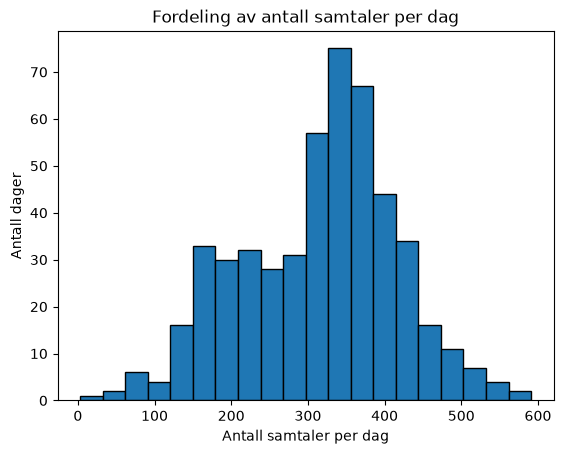

In [129]:
plt.hist(df_["antall_samtaler"], bins=20, edgecolor="black")
plt.title("Fordeling av antall samtaler per dag")
plt.xlabel("Antall samtaler per dag")
plt.ylabel("Antall dager")
plt.show()

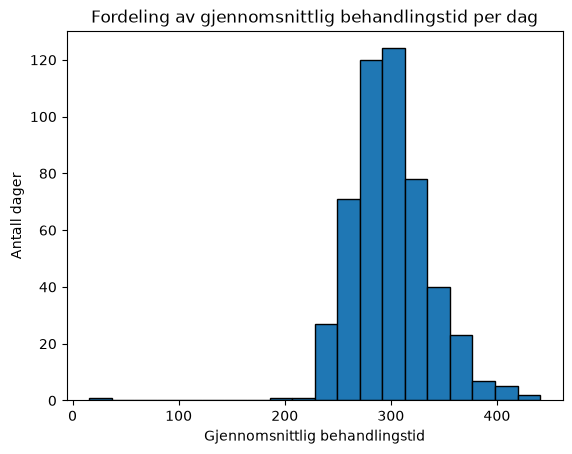

In [130]:
plt.hist(df_["behandlingstid_snitt"], bins=20, edgecolor="black")
plt.title("Fordeling av gjennomsnittlig behandlingstid per dag")
plt.xlabel("Gjennomsnittlig behandlingstid")
plt.ylabel("Antall dager")
plt.show()

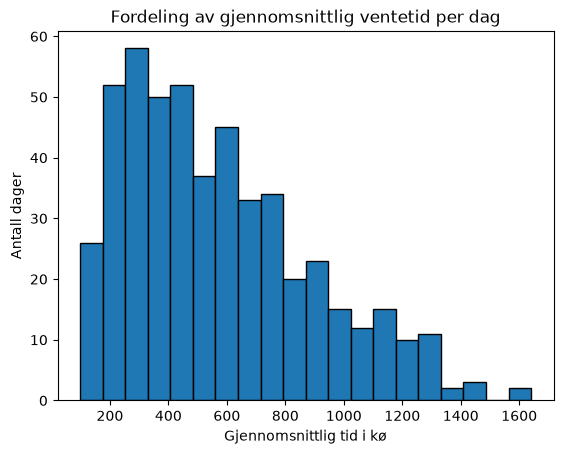

In [131]:
plt.hist(df_["tid_i_ko_snitt"], bins=20, edgecolor="black")
plt.title("Fordeling av gjennomsnittlig ventetid per dag")
plt.xlabel("Gjennomsnittlig tid i kø")
plt.ylabel("Antall dager")
plt.show()

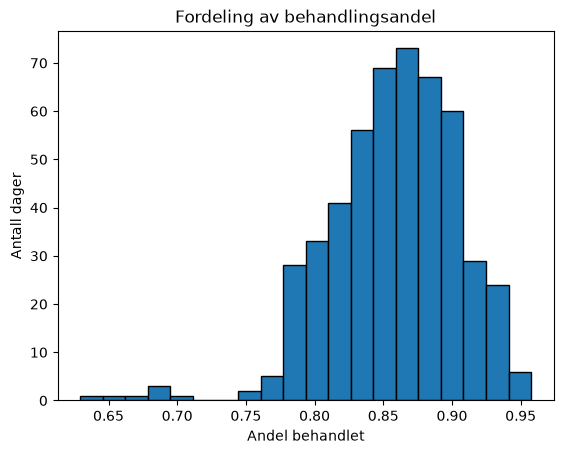

In [132]:
plt.hist(df_["behandlet_andel"], bins=20, edgecolor="black")
plt.title("Fordeling av behandlingsandel")
plt.xlabel("Andel behandlet")
plt.ylabel("Antall dager")
plt.show()

In [133]:
print(len(df_.columns))

116


### Modellering

In [134]:
# Fjerner noen kolonner: Beholder kun 30 dager bak, fjerner fremover og 7 dager bak. 
cols_to_remove = [
    "hf_dato",
    "antall_nye_kunder_b7_mpb01_ny",
    "antall_nye_kunder_f30_mpb01_ny",
    "antall_nye_kunder_f7_mpb01_ny",
    "antall_hf_b7_mpb01_ny",
    "antall_hf_f30_mpb01_ny",
    "antall_hf_f7_mpb01_ny",
    "antall_nye_kunder_b7_eph01_for",
    "antall_nye_kunder_f30_eph01_for",
    "antall_nye_kunder_f7_eph01_for",
    "antall_hf_b7_eph01_for",
    "stddev_premieendring_b7_eph01_for",
    "snitt_premieendring_b7_eph01_for",
    "antall_hf_f30_eph01_for",
    "stddev_premieendring_f30_eph01_for",
    "snitt_premieendring_f30_eph01_for",
    "antall_hf_f7_eph01_for",
    "stddev_premieendring_f7_eph01_for",
    "snitt_premieendring_f7_eph01_for",
    "antall_nye_kunder_b7_eph01_ny",
    "antall_nye_kunder_f30_eph01_ny",
    "antall_nye_kunder_f7_eph01_ny",
    "antall_hf_b7_eph01_ny",
    "antall_hf_f30_eph01_ny",
    "antall_hf_f7_eph01_ny",
    "antall_nye_kunder_b7_epf01_ny",
    "antall_nye_kunder_f30_epf01_ny",
    "antall_nye_kunder_f7_epf01_ny",
    "antall_hf_b7_epf01_ny",
    "antall_hf_f30_epf01_ny",
    "antall_hf_f7_epf01_ny",
    "antall_nye_kunder_b7_epf01_for",
    "antall_nye_kunder_f30_epf01_for",
    "antall_nye_kunder_f7_epf01_for",
    "antall_hf_b7_epf01_for",
    "stddev_premieendring_b7_epf01_for",
    "snitt_premieendring_b7_epf01_for",
    "antall_hf_f30_epf01_for",
    "stddev_premieendring_f30_epf01_for",
    "snitt_premieendring_f30_epf01_for",
    "antall_hf_f7_epf01_for",
    "stddev_premieendring_f7_epf01_for",
    "snitt_premieendring_f7_epf01_for",
    "antall_nye_kunder_b7_upr01_ny",
    "antall_nye_kunder_f30_upr01_ny",
    "antall_nye_kunder_f7_upr01_ny",
    "antall_hf_b7_upr01_ny",
    "antall_hf_f30_upr01_ny",
    "antall_hf_f7_upr01_ny",
    "antall_nye_kunder_b7_mpb01_for",
    "antall_nye_kunder_f30_mpb01_for",
    "antall_nye_kunder_f7_mpb01_for",
    "antall_hf_b7_mpb01_for",
    "stddev_premieendring_b7_mpb01_for",
    "snitt_premieendring_b7_mpb01_for",
    "antall_hf_f30_mpb01_for",
    "stddev_premieendring_f30_mpb01_for",
    "snitt_premieendring_f30_mpb01_for",
    "antall_hf_f7_mpb01_for",
    "stddev_premieendring_f7_mpb01_for",
    "snitt_premieendring_f7_mpb01_for",
    "antall_nye_kunder_b7_upr01_for",
    "antall_nye_kunder_f30_upr01_for",
    "antall_nye_kunder_f7_upr01_for",
    "antall_hf_b7_upr01_for",
    "stddev_premieendring_b7_upr01_for",
    "snitt_premieendring_b7_upr01_for",
    "antall_hf_f30_upr01_for",
    "stddev_premieendring_f30_upr01_for",
    "snitt_premieendring_f30_upr01_for",
    "antall_hf_f7_upr01_for",
    "stddev_premieendring_f7_upr01_for",
    "snitt_premieendring_f7_upr01_for"
]
df_ = df_.drop(columns=cols_to_remove)

In [ ]:
df_.head()
# df_.columns

,ankomst_dato,antall_samtaler,behandlet_andel,tid_i_ko_snitt,behandlingstid_snitt,total_behandlingstid,etterbehandligstid_snitt,total_etterbehandligstid,antall_nye_kunder_b30_mpb01_ny,antall_hf_b30_mpb01_ny,antall_nye_kunder_b30_eph01_for,antall_hf_b30_eph01_for,stddev_premieendring_b30_eph01_for,snitt_premieendring_b30_eph01_for,antall_nye_kunder_b30_eph01_ny,antall_hf_b30_eph01_ny,antall_nye_kunder_b30_epf01_ny,antall_hf_b30_epf01_ny,antall_nye_kunder_b30_epf01_for,antall_hf_b30_epf01_for,stddev_premieendring_b30_epf01_for,snitt_premieendring_b30_epf01_for,antall_nye_kunder_b30_upr01_ny,antall_hf_b30_upr01_ny,antall_nye_kunder_b30_mpb01_for,antall_hf_b30_mpb01_for,stddev_premieendring_b30_mpb01_for,snitt_premieendring_b30_mpb01_for,antall_nye_kunder_b30_upr01_for,antall_hf_b30_upr01_for,stddev_premieendring_b30_upr01_for,snitt_premieendring_b30_upr01_for,aar,kvartal,maaned,ukenummer,ukedag,dag_i_maaned,er_helg,helligdag,er_helligdag,er_dag_foer_helligdag,er_dag_etter_helligdag
0,2024-06-03,181,0.850829,274.342541,281.049724,50870,130.419890,23606,501,2900,96.0,4921.0,7.780343,1.119475,96.0,961.0,13.0,176.0,13.0,988.0,5.220043,1.076235,105,610,501.0,6558.0,7.516885,1.185686,105.0,2338.0,1.935644,1.032337,2024,2,6,23,1,3,0,None,0,0,0
1,2024-06-04,408,0.828431,732.632353,280.009804,114244,121.987745,49771,502,2907,89.0,4949.0,7.758312,1.121448,89.0,936.0,11.0,166.0,11.0,996.0,5.199079,1.076031,102,601,502.0,6586.0,7.459350,1.185899,102.0,2343.0,1.946560,1.032964,2024,2,6,23,2,4,0,None,0,0,0
2,2024-06-05,294,0.782313,650.248299,258.166667,75901,97.272109,28598,488,2880,85.0,4947.0,7.759890,1.121574,85.0,920.0,10.0,158.0,10.0,1023.0,5.130114,1.075870,104,606,488.0,6599.0,7.504770,1.186168,104.0,2356.0,1.941469,1.033941,2024,2,6,23,3,5,0,None,0,0,0
3,2024-06-06,313,0.808307,447.830671,294.220447,92091,91.447284,28623,474,2844,87.0,4975.0,7.738009,1.122787,87.0,925.0,9.0,155.0,9.0,1027.0,6.564680,1.081112,103,592,474.0,6627.0,7.799477,1.187572,103.0,2371.0,2.172918,1.034799,2024,2,6,23,4,6,0,None,0,0,0
4,2024-06-07,371,0.867925,791.533693,301.137466,111722,133.552561,49548,481,2890,87.0,4989.0,8.028814,1.123380,87.0,946.0,9.0,155.0,9.0,1024.0,6.574265,1.081179,105,603,481.0,6644.0,7.754416,1.187596,105.0,2373.0,2.172067,1.035438,2024,2,6,23,5,7,0,None,0,0,0


Importer statsmodels

In [137]:
import statsmodels.api as sm
import statsmodels.formula.api as smf



Repons: total behandlingstid. (Etterbehandling er IKKE inludert her!!)

In [142]:
model_ = smf.glm(
    # formula = "total_behandlingstid ~ antall_nye_kunder_b30_mpb01_ny + antall_hf_b30_mpb01_ny + antall_nye_kunder_b30_eph01_for + antall_hf_b30_eph01_for + stddev_premieendring_b30_eph01_for + snitt_premieendring_b30_eph01_for + antall_nye_kunder_b30_eph01_ny + antall_hf_b30_eph01_ny + antall_nye_kunder_b30_epf01_ny + antall_hf_b30_epf01_ny + antall_nye_kunder_b30_epf01_for + antall_hf_b30_epf01_for + stddev_premieendring_b30_epf01_for + snitt_premieendring_b30_epf01_for + antall_nye_kunder_b30_upr01_ny + antall_hf_b30_upr01_ny + antall_nye_kunder_b30_mpb01_for + antall_hf_b30_mpb01_for + stddev_premieendring_b30_mpb01_for + snitt_premieendring_b30_mpb01_for + antall_nye_kunder_b30_upr01_for + antall_hf_b30_upr01_for + stddev_premieendring_b30_upr01_for + snitt_premieendring_b30_upr01_for + aar + kvartal + maaned + ukenummer + ukedag + dag_i_maaned + er_dag_foer_helligdag + er_dag_etter_helligdag", 
    formula = "total_behandlingstid ~ C(ukedag) + C(aar) + C(kvartal) + C(er_dag_foer_helligdag) + C(er_dag_etter_helligdag)",
    data = df_,
    family=sm.families.NegativeBinomial()
).fit(cov_type="HC3")

print(model_.summary())

                  Generalized Linear Model Regression Results                   
Dep. Variable:     total_behandlingstid   No. Observations:                  500
Model:                              GLM   Df Residuals:                      487
Model Family:          NegativeBinomial   Df Model:                           12
Link Function:                      Log   Scale:                          1.0000
Method:                            IRLS   Log-Likelihood:                -6207.9
Date:                  Mon, 29 Jun 2026   Deviance:                       44.152
Time:                          15:54:38   Pearson chi2:                     37.7
No. Iterations:                      11   Pseudo R-squ. (CS):            0.05623
Covariance Type:                    HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

c:\Users\ra5\Workspaces\inngangsanalyse\.venv\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "
